Pemmodelan Konseptual (Berbasis Rumus)

nilai t : [0.         0.26315789 0.52631579 0.78947368 1.05263158 1.31578947
 1.57894737 1.84210526 2.10526316 2.36842105 2.63157895 2.89473684
 3.15789474 3.42105263 3.68421053 3.94736842 4.21052632 4.47368421
 4.73684211 5.        ]


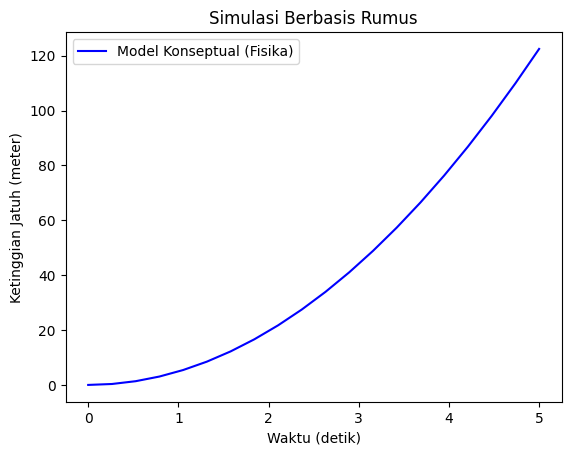

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definisi konstanta oleh pakar (Manusia)
g = 9.8 #Gravitasi bumi
t = np.linspace(0, 5, 20) # Waktu 0 sampai 5 detik (20 titik data)

print(f"nilai t : {t}")
# Model konseptual : Rumus eksplisit
# Rumus  gerak  jatuh bebas
h_konseptual = 0.5 * g * t**2

plt.plot(t, h_konseptual, label='Model Konseptual (Fisika)', color='blue')
plt.xlabel('Waktu (detik)')
plt.ylabel('Ketinggian Jatuh (meter)')
plt.legend()
plt.title('Simulasi Berbasis Rumus')
plt.show()

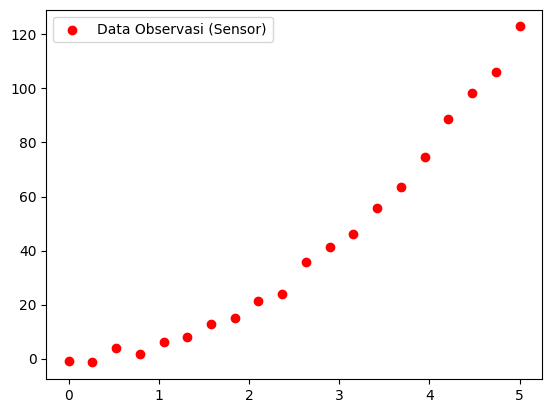

In [2]:
# Menambahkan 'noise' untuk mensimulasikan ketidakpastian dunia nyata
noise = np.random.normal(0, 2, len(t))
h_observasi = h_konseptual + noise
plt.scatter(t, h_observasi, color='red', label='Data Observasi (Sensor)')
plt.legend()
plt.show()

Pemodelan Berbasis Data (Machine Learning)

In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


In [4]:
# Mengubah t menjadi format matriks untuk input ML
t_input = t.reshape(-1, 1)

In [5]:
# Menggunakan Regresi Polinomial karena kita menduga hubungannya non-linear
poly = PolynomialFeatures(degree=2)
t_poly = poly.fit_transform(t_input)

In [6]:
# Proses 'Learning'
model_ml = LinearRegression()
model_ml.fit(t_poly, h_observasi)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
# Prediksi hasil belajar mesin
h_prediksi_ml = model_ml.predict(t_poly)

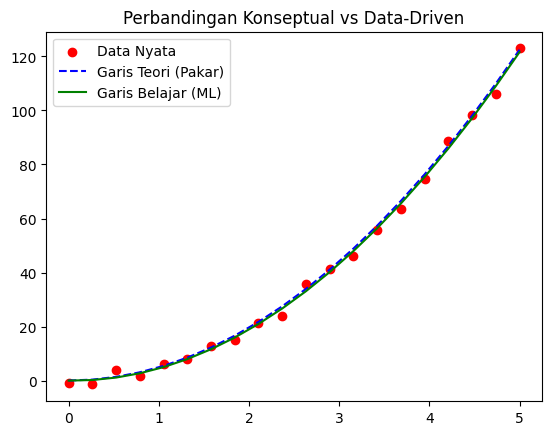

In [8]:
# Visualisasi Perbandingan
plt.scatter(t, h_observasi, color='red', label='Data Nyata')
plt.plot(t, h_konseptual, 'b--', label='Garis Teori (Pakar)')
plt.plot(t, h_prediksi_ml, 'g', label='Garis Belajar (ML)')
plt.legend()
plt.title('Perbandingan Konseptual vs Data-Driven')
plt.show()